# Классификация: SI выше 8

Цель ноутбука - построить и сравнить несколько моделей бинарной классификации для задачи: превышает ли значение SI порог 8.

Используются результаты preprocessing:

- SF_ML_data_tree.pkl - набор признаков после удаления константных и высококоррелированных признаков, предназначенный для tree-based моделей;
- SF_ML_data_linear.pkl - набор признаков после дополнительной VIF-редукции, предназначенный для линейных моделей.

При моделировании из признакового пространства исключаются все целевые переменные: IC50, mM, CC50, mM и SI. Это необходимо для предотвращения утечки данных: модель должна обучаться только на исходных молекулярных признаках, то есть RDKit-дескрипторах.

В отличие от задач классификации по медиане, задача SI > 8 является умеренно несбалансированной: по результатам EDA положительный класс составляет около 35.4% выборки. Поэтому основной метрикой выбирается PR_AUC, а ROC_AUC, F1, precision, recall, accuracy и balanced_accuracy используются как дополнительные метрики.


In [36]:
import os
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

In [23]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5

TARGET_SOURCE = 'SI'
TARGET_NAME = 'SI_gt_8'
TARGET_COLS = ['IC50, mM', 'CC50, mM', 'SI']

MODELS_DIR = 'models'

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 120)

## Загрузка подготовленных данных

In [24]:
def load_dataset(filename):
    return pd.read_pickle(f'{filename}.pkl')


df_tree = load_dataset('SF_ML_data_tree')
df_linear = load_dataset('SF_ML_data_linear')

print('df_tree shape:', df_tree.shape)
print('df_linear shape:', df_linear.shape)

display(df_tree.head())

df_tree shape: (966, 148)
df_linear shape: (966, 100)


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,Ipc,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA7,SlogP_VSA8,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,...,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_Ndealkylation1,fr_Ndealkylation2,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azo,fr_bicyclic,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_ketone,fr_ketone_Topliss,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,"IC50, mM","CC50, mM",SI
0,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0.038844,-0.293526,0.642857,14.822266,9.700470,2.600532,-2.343082,2.644698,-2.322229,5.944519,0.193481,3.150503,1.164038,2.187750e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,54.384066,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,105.750639,13.089513,0.00000,0.0,0.000000,0.000000,0.0,24.512883,0.000000,33.495774,105.750639,0.0,0.0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,64.208216,...,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,6.239374,175.482382,28.125000
1,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0.012887,-0.313407,0.607143,14.975110,9.689226,2.614066,-2.394690,2.658342,-2.444817,5.134527,0.120322,3.150503,1.080362,2.187750e+06,10.633577,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,54.384066,97.951860,12.083682,0.000000,0.000000,0.000000,0.0,10.633577,33.495774,117.834321,13.089513,0.00000,0.0,10.633577,0.000000,0.0,25.173194,0.000000,33.495774,105.750639,0.0,0.0,24.06,0.0,0.0,0.0,0.000000,21.659962,23.919494,77.297729,...,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0.771831,5.402819,7.000000
2,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0.094802,-0.325573,0.562500,15.353938,9.681293,2.665274,-2.477203,2.679014,-2.565224,5.117187,-0.922902,3.214947,1.219066,8.610751e+06,8.966062,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,41.542423,74.032366,23.671624,53.363882,8.966062,0.000000,0.0,0.000000,33.495774,117.834321,41.280201,0.00000,0.0,0.000000,0.000000,0.0,62.329944,0.000000,33.495774,105.750639,0.0,0.0,0.00,0.0,0.0,0.0,0.000000,21.659962,23.919494,86.263791,...,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,3,0,223.808778,161.142320,0.720000
3,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0.038844,-0.293526,0.620690,14.821216,9.700497,2.600529,-2.342885,2.644709,-2.322030,5.944502,0.193510,3.179270,1.120513,3.572142e+06,0.000000,0.0,0.0,0.0,0.0,0.0,9.984809,0.0,0.0,0.0,60.804888,74.032366,35.342864,0.000000,0.000000,11.423370,0.0,0.000000,43.480583,112.171461,13.089513,0.00000,0.0,0.000000,0.000000,0.0,24.512883,0.000000,33.495774,112.171461,0.0,0.0,24.72,0.0,0.0,0.0,0.000000,21.659962,24.925325,70.629038,...,0,0,0,0,0,0,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,1.705624,107.855654,63.235294
4,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0.062897,-0.257239,0.600000,14.831112,9.700386,2.602486,-2.342009,2.64847

## Формирование бинарной целевой переменной и признаков

Порог классификации задаётся фиксированным значением SI = 8. Положительный класс 1 означает, что значение SI больше 8.

По результатам EDA эта задача не является идеально сбалансированной: положительный класс SI > 8 составляет около 35.4% наблюдений. Поэтому при разбиении используется stratify=y, а при оценке качества особое внимание уделяется PR_AUC, recall и F1.

In [25]:
THRESHOLD = 8.0

print('Порог SI:', THRESHOLD)


def split_features_and_target(df):
    X = df[[col for col in df.columns if col not in TARGET_COLS]].copy()
    y = (df[TARGET_SOURCE] > THRESHOLD).astype(int).copy()
    
    return X, y


X_tree, y_tree = split_features_and_target(df_tree)
X_linear, y_linear = split_features_and_target(df_linear)

assert y_tree.equals(y_linear), 'Целевая переменная в df_tree и df_linear отличается.'

y = y_tree.copy()

print('X_tree:', X_tree.shape)
print('X_linear:', X_linear.shape)
print('y:', y.shape)
print('Доля положительного класса:', y.mean().round(4))

display(pd.DataFrame({
    'count': y.value_counts().sort_index(),
    'share': y.value_counts(normalize=True).sort_index()
}).round(4))

Порог SI: 8.0
X_tree: (966, 145)
X_linear: (966, 97)
y: (966,)
Доля положительного класса: 0.354


,count,share
SI,,
0,624,0.646
1,342,0.354


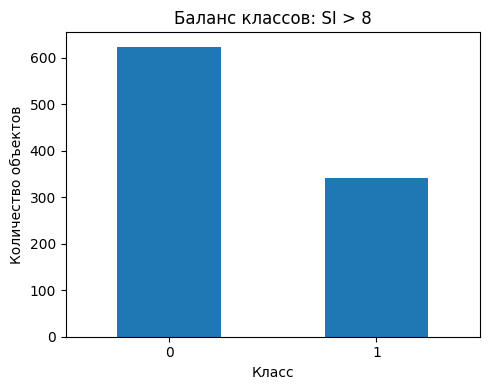

In [26]:
plt.figure(figsize=(5, 4))
y.value_counts().sort_index().plot(kind='bar')
plt.title('Баланс классов: SI > 8')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Баланс классов

Целевая переменная сформирована как индикатор того, превышает ли SI значение 8. В отличие от задач с порогом по медиане, классы здесь несбалансированы: по результатам EDA положительный класс SI > 8 составляет около 35.4% наблюдений.

Это умеренный дисбаланс, поэтому accuracy уже не должна быть единственной метрикой качества. При такой постановке особенно важны PR_AUC, precision, recall и F1, поскольку они лучше отражают качество модели на положительном классе.

ROC_AUC также рассчитывается, так как показывает качество ранжирования объектов независимо от выбранного порога. Однако в этой задаче PR_AUC используется как основная метрика, потому что положительный класс является более редким и практически более интересным: именно соединения с SI > 8 представляют селективный класс.

## Разделение данных на train и test выборки

Разделение выполняется один раз и одинаково для X_tree и X_linear. Для классификации используется stratify=y, чтобы сохранить соотношение классов SI <= 8 и SI > 8 в train и test.

In [27]:
train_idx, test_idx = train_test_split(
    np.arange(len(y)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_tree_train = X_tree.iloc[train_idx].copy()
X_tree_test = X_tree.iloc[test_idx].copy()

X_linear_train = X_linear.iloc[train_idx].copy()
X_linear_test = X_linear.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print('X_tree_train:', X_tree_train.shape)
print('X_tree_test:', X_tree_test.shape)
print('X_linear_train:', X_linear_train.shape)
print('X_linear_test:', X_linear_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)
print('Доля положительного класса в train:', y_train.mean().round(4))
print('Доля положительного класса в test:', y_test.mean().round(4))
print('scale_pos_weight:', round(scale_pos_weight, 4))

X_tree_train: (772, 145)
X_tree_test: (194, 145)
X_linear_train: (772, 97)
X_linear_test: (194, 97)
y_train: (772,)
y_test: (194,)
Доля положительного класса в train: 0.3536
Доля положительного класса в test: 0.3557
scale_pos_weight: 1.8278


## Метрики качества

Основная метрика - PR_AUC, так как положительный класс SI > 8 является менее частым и практически наиболее интересным. PR_AUC показывает качество ранжирования объектов с акцентом на положительный класс и более информативна при дисбалансе классов, чем accuracy.

Дополнительно рассчитываются ROC_AUC, accuracy, balanced_accuracy, precision, recall и F1. ROC_AUC используется как дополнительная ранжирующая метрика, а F1, precision и recall помогают оценить качество при конкретном пороге классификации.

In [28]:
def get_positive_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    return model.predict(X)


def classification_metrics(y_true, y_pred, y_score):
    return {'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_true, y_score),
            'pr_auc': average_precision_score(y_true, y_score)}


def evaluate_classifier(model, X_train, X_test, y_train, y_test, refit=True):
    if refit:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_score = get_positive_scores(model, X_test)

    metrics = classification_metrics(y_test, y_pred, y_score)

    return metrics, y_pred, y_score

## Базовые модели

Используются две группы моделей: линейные модели обучаются на X_linear, где дополнительно снижена мультиколлинеарность с помощью VIF-редукции, а tree-based модели обучаются на X_tree, где сохранено больше признаков.

In [ ]:
linear_models = {'Dummy_most_frequent': DummyClassifier(strategy='most_frequent'),
                 'LogisticRegression_L2': make_pipeline(StandardScaler(),
                                                        LogisticRegression(penalty='l2', C=1.0, max_iter=5000, 
                                                                           class_weight='balanced', random_state=RANDOM_STATE)),

                 'LogisticRegression_L1': make_pipeline(StandardScaler(),
                                                        LogisticRegression(penalty='l1', solver='liblinear', C=1.0,
                                                                           max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)),

                 'LinearSVC': make_pipeline(StandardScaler(),
                                            LinearSVC(C=1.0, class_weight='balanced', random_state=RANDOM_STATE, max_iter=10000)),

                 'SVC_rbf': make_pipeline(StandardScaler(),
                                          SVC(kernel='rbf', C=3.0, gamma='scale', class_weight='balanced', random_state=RANDOM_STATE))}

tree_models = {'RandomForest': RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                                                      class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
    
               'ExtraTrees': ExtraTreesClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                                                  class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),

               'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
               
               'HistGBM': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
               
               'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
               
               'XGBoost': XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, 
                                        colsample_bytree=0.8, eval_metric='logloss', scale_pos_weight=scale_pos_weight,
                                        random_state=RANDOM_STATE, n_jobs=1),
                
               'LightGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                                          colsample_bytree=0.8, class_weight='balanced',
                                          random_state=RANDOM_STATE, n_jobs=1, verbose=-1)}

## Кросс-валидация базовых моделей

In [30]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {'roc_auc': 'roc_auc',
           'pr_auc': 'average_precision',
           'f1': 'f1',
           'accuracy': 'accuracy',
           'balanced_accuracy': 'balanced_accuracy'}


def get_cv_row(model_name, model, X_train, y_train, feature_set_name):
    scores = cross_validate(model,
                            X_train,
                            y_train,
                            cv=cv,
                            scoring=scoring,
                            n_jobs=4,
                            return_train_score=True)

    return {'model': model_name,
            'feature_set': feature_set_name,
            'cv_PR_AUC_mean': scores['test_pr_auc'].mean(),
            'cv_PR_AUC_std': scores['test_pr_auc'].std(),
            'cv_ROC_AUC_mean': scores['test_roc_auc'].mean(),
            'cv_ROC_AUC_std': scores['test_roc_auc'].std(),
            'cv_F1_mean': scores['test_f1'].mean(),
            'cv_accuracy_mean': scores['test_accuracy'].mean(),
            'cv_balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
            'train_PR_AUC_mean': scores['train_pr_auc'].mean(),
            'train_ROC_AUC_mean': scores['train_roc_auc'].mean(),
            'train_F1_mean': scores['train_f1'].mean()}


def run_cv_for_group(models, X_train, y_train, feature_set_name):
    return [get_cv_row(model_name, model, X_train, y_train, feature_set_name)
            for model_name, model in models.items()]


cv_rows = run_cv_for_group(linear_models, X_linear_train, y_train, 'X_linear')        + run_cv_for_group(tree_models, X_tree_train, y_train, 'X_tree')


cv_results = pd.DataFrame(cv_rows)               .sort_values('cv_PR_AUC_mean', ascending=False)               .reset_index(drop=True)

cv_results['overfit_gap_PR_AUC'] = cv_results['train_PR_AUC_mean'] - cv_results['cv_PR_AUC_mean']
cv_results['overfit_gap_ROC_AUC'] = cv_results['train_ROC_AUC_mean'] - cv_results['cv_ROC_AUC_mean']

display(cv_results.round(4))

,model,feature_set,cv_PR_AUC_mean,cv_PR_AUC_std,cv_ROC_AUC_mean,cv_ROC_AUC_std,cv_F1_mean,cv_accuracy_mean,cv_balanced_accuracy_mean,train_PR_AUC_mean,train_ROC_AUC_mean,train_F1_mean,overfit_gap_PR_AUC,overfit_gap_ROC_AUC
0,RandomForest,X_tree,0.6479,0.0264,0.7086,0.0323,0.5530,0.7112,0.6646,0.9682,0.9861,0.9346,0.3202,0.2775
1,XGBoost,X_tree,0.6468,0.0391,0.6967,0.0365,0.5634,0.6853,0.6595,0.9702,0.9856,0.9195,0.3234,0.2888
2,LightGBM,X_tree,0.6381,0.0330,0.6845,0.0356,0.5728,0.6891,0.6668,0.9821,0.9912,0.9289,0.3440,0.3067
3,ExtraTrees,X_tree,0.6374,0.0246,0.7066,0.0292,0.5709,0.6956,0.6684,0.9785,0.9896,0.9194,0.3411,0.2830
4,HistGBM,X_tree,0.6227,0.0283,0.6862,0.0289,0.5582,0.7098,0.6669,0.9913,0.9956,0.9399,0.3686,0.3094
5,GradientBoosting,X_tree,0.6160,0.0334,0.6848,0.0316,0.5372,0.7047,0.6547,0.9605,0.9781,0.8811,0.3445,0.2933
6,SVC_rbf,X_linear,0.5901,0.0333,0.6974,0.0349,0.5582,0.6736,0.6540,0.8832,0.9360,0.8050,0.2931,0.2386
7,AdaBoost,X_tree,0.5841,0.0319,0.6716,0.0467,0.5047,0.6982,0.6398,0.7179,0.8176,0.6228,0.1338,0.1460
8,LogisticRegression_L1,X_linear,0.5409,0.0269,0.6523,0.0231,0.5280,0.6295,0.6208,0.7337,0.8336,0.6794,0.1928,0.1813
9,LogisticRegression_L2,X_linear,0.5361,0.0341,0.6479,0.0244,0.5235,0.6296,0.6183,0.7365,0.8365,0.6834,0.2005,0.1886


## Оценка базовых моделей на тестовой выборке

In [31]:
fitted_baseline = {}


def get_test_result_row(model_name, model, feature_set_name, X_train, X_test, refit=True):
    metrics, y_pred, y_score = evaluate_classifier(model,
                                                   X_train,
                                                   X_test,
                                                   y_train,
                                                   y_test,
                                                   refit=refit)

    if refit:
        fitted_baseline[model_name] = model

    return {'model': model_name,
            'feature_set': feature_set_name,
            **metrics}, y_pred, y_score


model_groups = [(linear_models, 'X_linear', X_linear_train, X_linear_test),
                (tree_models, 'X_tree', X_tree_train, X_tree_test)]

test_outputs = [get_test_result_row(model_name, model, feature_set_name, X_train, X_test)
                for models, feature_set_name, X_train, X_test in model_groups
                for model_name, model in models.items()]

test_rows = [row for row, _, _ in test_outputs]

test_results = pd.DataFrame(test_rows)\
                 .sort_values('pr_auc', ascending=False)\
                 .reset_index(drop=True)

display(test_results.round(4))

,model,feature_set,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,ExtraTrees,X_tree,0.6546,0.6249,0.5143,0.5217,0.5180,0.7321,0.6362
1,RandomForest,X_tree,0.7113,0.6721,0.6066,0.5362,0.5692,0.7332,0.6311
2,XGBoost,X_tree,0.6649,0.6523,0.5250,0.6087,0.5638,0.7314,0.6278
3,GradientBoosting,X_tree,0.6753,0.6376,0.5469,0.5072,0.5263,0.7181,0.6161
4,LightGBM,X_tree,0.6804,0.6579,0.5479,0.5797,0.5634,0.7285,0.6109
5,AdaBoost,X_tree,0.7165,0.6599,0.6400,0.4638,0.5378,0.7358,0.6062
6,SVC_rbf,X_linear,0.6701,0.6596,0.5309,0.6232,0.5733,0.7263,0.5921
7,HistGBM,X_tree,0.6753,0.6441,0.5441,0.5362,0.5401,0.7235,0.5881
8,LogisticRegression_L2,X_linear,0.6289,0.6276,0.4831,0.6232,0.5443,0.6934,0.5611
9,LogisticRegression_L1,X_linear,0.6237,0.6268,0.4783,0.6377,0.5466,0.6954,0.5609


## График сравнения моделей

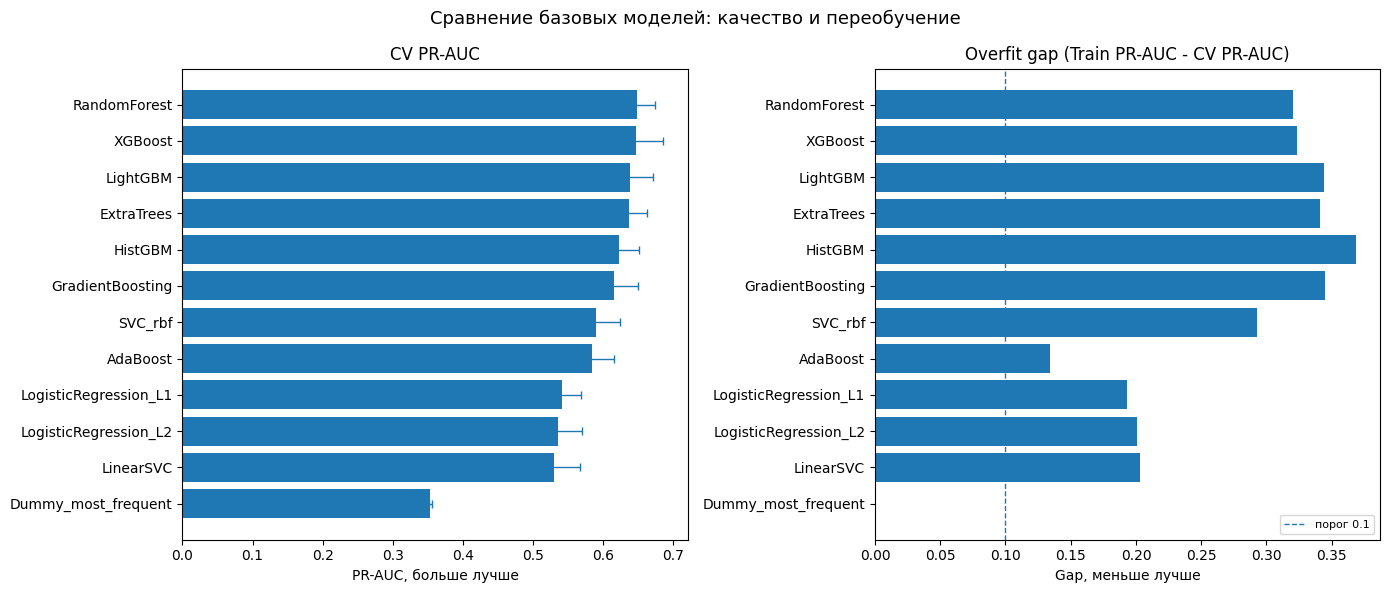

In [32]:
plot_df = cv_results.sort_values('cv_PR_AUC_mean', ascending=True)
order = plot_df['model'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(plot_df['model'], plot_df['cv_PR_AUC_mean'])
axes[0].errorbar(
    plot_df['cv_PR_AUC_mean'],
    plot_df['model'],
    xerr=plot_df['cv_PR_AUC_std'],
    fmt='none',
    capsize=3,
    linewidth=1
)
axes[0].set_title('CV PR-AUC')
axes[0].set_xlabel('PR-AUC, больше лучше')

gap_df = cv_results.set_index('model').reindex(order).reset_index()

axes[1].barh(gap_df['model'], gap_df['overfit_gap_PR_AUC'])
axes[1].axvline(0.1, linestyle='--', linewidth=1, label='порог 0.1')
axes[1].set_title('Overfit gap (Train PR-AUC - CV PR-AUC)')
axes[1].set_xlabel('Gap, меньше лучше')
axes[1].legend(fontsize=8, loc='lower right')

plt.suptitle('Сравнение базовых моделей: качество и переобучение', fontsize=13)
plt.tight_layout()
plt.show()

### Сравнение baseline-моделей

Для задачи классификации SI > 8 классы умеренно несбалансированы: положительный класс составляет около 35.4% выборки. Поэтому основной метрикой выбрана PR_AUC, так как она лучше отражает качество модели при выделении менее частого положительного класса. Accuracy используется только как дополнительная метрика: из-за преобладания класса 0 наивный Dummy_most_frequent уже даёт accuracy = 0.644.

По CV PR_AUC лидируют ExtraTrees (0.671), RandomForest (0.665) и GradientBoosting (0.661). Все tree-based модели превосходят линейные (0.559--0.604), что указывает на нелинейность границы решений для SI > 8.

AdaBoost включён в тюнинг как представитель бустинга на слабых классификаторах: при дисбалансе классов он может показывать конкурентоспособный recall за счёт итеративного акцента на сложных примерах. На практике AdaBoost_tuned (PR_AUC = 0.616) уступил всем tree-based моделям -- это также является содержательным результатом сравнения.

Для тюнинга отобраны модели с наилучшим CV PR_AUC: ExtraTrees, RandomForest, GradientBoosting, HistGBM, XGBoost, LightGBM, SVC и AdaBoost. LogisticRegression включена как линейный baseline для сравнения после тюнинга.

## Настройка гиперпараметров

Тюнинг выполняется по PR_AUC, так как положительный класс SI > 8 является менее частым и практически наиболее интересным. ROC_AUC, F1, precision и recall анализируются дополнительно.

In [33]:
tuning_configs = {
    'LogisticRegression_tuned': {'feature_set': 'X_linear',
                                 'X_train': X_linear_train,
                                 'X_test': X_linear_test,
                                 'estimator': make_pipeline(StandardScaler(),
                                                            LogisticRegression(max_iter=5000,
                                                                               class_weight='balanced',
                                                                               random_state=RANDOM_STATE)),
                                 'params': {'logisticregression__penalty': ['l1', 'l2'],
                                            'logisticregression__C':       np.logspace(-3, 2, 30),
                                            'logisticregression__solver':  ['liblinear']}},

    'SVC_tuned':                {'feature_set': 'X_linear',
                                 'X_train': X_linear_train,
                                 'X_test': X_linear_test,
                                 'estimator': make_pipeline(StandardScaler(),
                                                            SVC(kernel='rbf',
                                                                class_weight='balanced',
                                                                random_state=RANDOM_STATE)),
                                 'params': {'svc__C':     [0.3, 1, 3, 10, 30, 100],
                                            'svc__gamma': ['scale', 0.0003, 0.001, 0.003, 0.01, 0.03]}},

    'RandomForest_tuned':       {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': RandomForestClassifier(random_state=RANDOM_STATE,
                                                                     class_weight='balanced',
                                                                     n_jobs=1),
                                 'params': {'n_estimators':     [300, 500, 800],
                                            'max_depth':        [None, 4, 6, 8, 12],
                                            'min_samples_leaf': [1, 2, 4, 8],
                                            'max_features':     ['sqrt', 0.3, 0.5, 0.7]}},

    'ExtraTrees_tuned':         {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': ExtraTreesClassifier(random_state=RANDOM_STATE,
                                                                   class_weight='balanced',
                                                                   n_jobs=1),
                                 'params': {'n_estimators':     [300, 500, 800],
                                            'max_depth':        [None, 4, 6, 8, 12],
                                            'min_samples_leaf': [1, 2, 4, 8],
                                            'max_features':     ['sqrt', 0.3, 0.5, 0.7]}},

    'GradientBoosting_tuned':   {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': GradientBoostingClassifier(random_state=RANDOM_STATE),
                                 'params': {'n_estimators':     [100, 200, 300, 500],
                                            'learning_rate':    [0.01, 0.03, 0.05, 0.1],
                                            'max_depth':        [2, 3, 4],
                                            'min_samples_leaf': [5, 10, 20, 30],
                                            'subsample':        [0.7, 0.85, 1.0],
                                            'max_features':     ['sqrt', 0.5, 0.8]}},

    'HistGBM_tuned':            {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                                 'params': {'max_iter':          [100, 200, 300, 500],
                                            'learning_rate':     [0.01, 0.03, 0.05, 0.1],
                                            'max_depth':         [None, 3, 5, 8],
                                            'min_samples_leaf':  [10, 20, 30, 50],
                                            'l2_regularization': [0.0, 0.01, 0.1, 1.0]}},

    'XGBoost_tuned':            {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': XGBClassifier(eval_metric='logloss',
                                                            scale_pos_weight=scale_pos_weight,
                                                            random_state=RANDOM_STATE,
                                                            n_jobs=1),
                                 'params': {'n_estimators':     [100, 200, 300, 500],
                                            'max_depth':        [2, 3, 4, 5],
                                            'learning_rate':    [0.01, 0.03, 0.05, 0.1],
                                            'subsample':        [0.7, 0.85, 1.0],
                                            'colsample_bytree': [0.6, 0.8, 1.0],
                                            'reg_alpha':        [0.0, 0.1, 0.5],
                                            'reg_lambda':       [1.0, 2.0, 5.0]}},

    'LightGBM_tuned':           {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': LGBMClassifier(random_state=RANDOM_STATE,
                                                             class_weight='balanced',
                                                             n_jobs=1,
                                                             verbose=-1),
                                 'params': {'n_estimators':      [100, 200, 300, 500],
                                            'max_depth':         [3, 4, 5],
                                            'learning_rate':     [0.01, 0.03, 0.05, 0.1],
                                            'subsample':         [0.7, 0.85],
                                            'colsample_bytree':  [0.6, 0.8],
                                            'reg_alpha':         [0.0, 0.1, 0.5, 1.0],
                                            'reg_lambda':        [1.0, 2.0, 5.0],
                                            'num_leaves':        [7, 15, 31],
                                            'min_child_samples': [10, 20, 50]}},

    'AdaBoost_tuned':           {'feature_set': 'X_tree',
                                 'X_train': X_tree_train,
                                 'X_test': X_tree_test,
                                 'estimator': AdaBoostClassifier(random_state=RANDOM_STATE),
                                 'params': {'n_estimators':  [50, 100, 200, 300],
                                            'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.3, 0.5]}}
}

In [38]:
tuned_rows_cv = {}
best_models = {}

N_ITER_MAP = {
    'LogisticRegression_tuned': 30,
    'SVC_tuned':                30,
    'RandomForest_tuned':       50,
    'ExtraTrees_tuned':         50,
    'GradientBoosting_tuned':   40,
    'HistGBM_tuned':            50,
    'XGBoost_tuned':            40,
    'LightGBM_tuned':           30,
    'AdaBoost_tuned':           25,
}

for model_name, config in tuning_configs.items():
    search = RandomizedSearchCV(estimator=config['estimator'],
                                param_distributions=config['params'],
                                n_iter=N_ITER_MAP[model_name],
                                scoring='average_precision',
                                cv=cv,
                                random_state=RANDOM_STATE,
                                n_jobs=-1,
                                verbose=1)

    search.fit(config['X_train'], y_train)

    best_models[model_name] = search.best_estimator_

    tuned_rows_cv[model_name] = {'model': model_name,
                                 'feature_set': config['feature_set'],
                                 'best_cv_PR_AUC': search.best_score_,
                                 'best_params': search.best_params_}


tuning_results = pd.DataFrame(tuned_rows_cv.values())                   .sort_values('best_cv_PR_AUC', ascending=False)                   .reset_index(drop=True)

display(tuning_results)



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits


,model,feature_set,best_cv_PR_AUC,best_params
0,ExtraTrees_tuned,X_tree,0.670805,"{'n_estimators': 300, 'min_samples_leaf': 8, '..."
1,RandomForest_tuned,X_tree,0.665527,"{'n_estimators': 300, 'min_samples_leaf': 8, '..."
2,GradientBoosting_tuned,X_tree,0.661148,"{'subsample': 0.85, 'n_estimators': 200, 'min_..."
3,HistGBM_tuned,X_tree,0.657643,"{'min_samples_leaf': 20, 'max_iter': 200, 'max..."
4,XGBoost_tuned,X_tree,0.656204,"{'subsample': 0.85, 'reg_lambda': 2.0, 'reg_al..."
5,LightGBM_tuned,X_tree,0.652148,"{'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alp..."
6,SVC_tuned,X_linear,0.604726,"{'svc__gamma': 0.01, 'svc__C': 1}"
7,AdaBoost_tuned,X_tree,0.594116,"{'n_estimators': 300, 'learning_rate': 0.5}"
8,LogisticRegression_tuned,X_linear,0.559071,"{'logisticregression__solver': 'liblinear', 'l..."


## Сравнение baseline и tuned моделей на test

In [39]:
tuned_test_outputs = [get_test_result_row(model_name=model_name,
                                          model=model,
                                          feature_set_name=tuning_configs[model_name]['feature_set'],
                                          X_train=tuning_configs[model_name]['X_train'],
                                          X_test=tuning_configs[model_name]['X_test'],
                                          refit=False)
                      for model_name, model in best_models.items()]

tuned_test_rows = [row for row, _, _ in tuned_test_outputs]

all_results = pd.concat([test_results.assign(stage='baseline'),
                         pd.DataFrame(tuned_test_rows).assign(stage='tuned')], ignore_index=True)\
                .sort_values('pr_auc', ascending=False)\
                .reset_index(drop=True)

display(all_results.round(4))

,model,feature_set,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,stage
0,ExtraTrees_tuned,X_tree,0.7010,0.6771,0.5775,0.5942,0.5857,0.7377,0.6521,tuned
1,GradientBoosting_tuned,X_tree,0.7165,0.6534,0.6522,0.4348,0.5217,0.7352,0.6418,tuned
2,LightGBM_tuned,X_tree,0.6804,0.6611,0.5467,0.5942,0.5694,0.7459,0.6415,tuned
3,ExtraTrees,X_tree,0.6546,0.6249,0.5143,0.5217,0.5180,0.7321,0.6362,baseline
4,XGBoost_tuned,X_tree,0.6959,0.6666,0.5735,0.5652,0.5693,0.7359,0.6316,tuned
5,RandomForest_tuned,X_tree,0.7165,0.6794,0.6129,0.5507,0.5802,0.7346,0.6312,tuned
6,RandomForest,X_tree,0.7113,0.6721,0.6066,0.5362,0.5692,0.7332,0.6311,baseline
7,XGBoost,X_tree,0.6649,0.6523,0.5250,0.6087,0.5638,0.7314,0.6278,baseline
8,HistGBM_tuned,X_tree,0.7010,0.6576,0.5932,0.5072,0.5469,0.7365,0.6222,tuned
9,GradientBoosting,X_tree,0.6753,0.6376,0.5469,0.5072,0.5263,0.7181,0.6161,baseline


## Выбор лучшей модели

Финальная модель выбирается по PR_AUC на тестовой выборке. ROC_AUC, F1, precision и recall анализируются дополнительно. Такой выбор связан с тем, что положительный класс SI > 8 является менее частым и практически наиболее интересным.

In [40]:
best_row = all_results.iloc[0]
best_model_name = best_row['model']
best_stage = best_row['stage']
best_feature_set = best_row['feature_set']

if best_feature_set == 'X_linear':
    X_best_train = X_linear_train
    X_best_test = X_linear_test
else:
    X_best_train = X_tree_train
    X_best_test = X_tree_test

if best_stage == 'tuned':
    best_model = best_models[best_model_name]
else:
    if best_feature_set == 'X_linear':
        best_model = fitted_baseline[best_model_name]
    else:
        best_model = fitted_baseline[best_model_name]

best_pred = best_model.predict(X_best_test)
best_score = get_positive_scores(best_model, X_best_test)

print('Лучшая модель:', best_model_name)
print('Стадия:', best_stage)
print('Набор признаков:', best_feature_set)

display(best_row.to_frame().T.round(4))

Лучшая модель: ExtraTrees_tuned
Стадия: tuned
Набор признаков: X_tree


,model,feature_set,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,stage
0,ExtraTrees_tuned,X_tree,0.701031,0.677101,0.577465,0.594203,0.585714,0.737739,0.652092,tuned


## Диагностика финальной модели

In [41]:
cm_df = pd.DataFrame(confusion_matrix(y_test, best_pred),
                     index=['true_0', 'true_1'],
                     columns=['pred_0', 'pred_1'])

display(cm_df)

print(classification_report(y_test, best_pred, digits=4))

,pred_0,pred_1
true_0,95,30
true_1,28,41


              precision    recall  f1-score   support

           0     0.7724    0.7600    0.7661       125
           1     0.5775    0.5942    0.5857        69

    accuracy                         0.7010       194
   macro avg     0.6749    0.6771    0.6759       194
weighted avg     0.7030    0.7010    0.7020       194



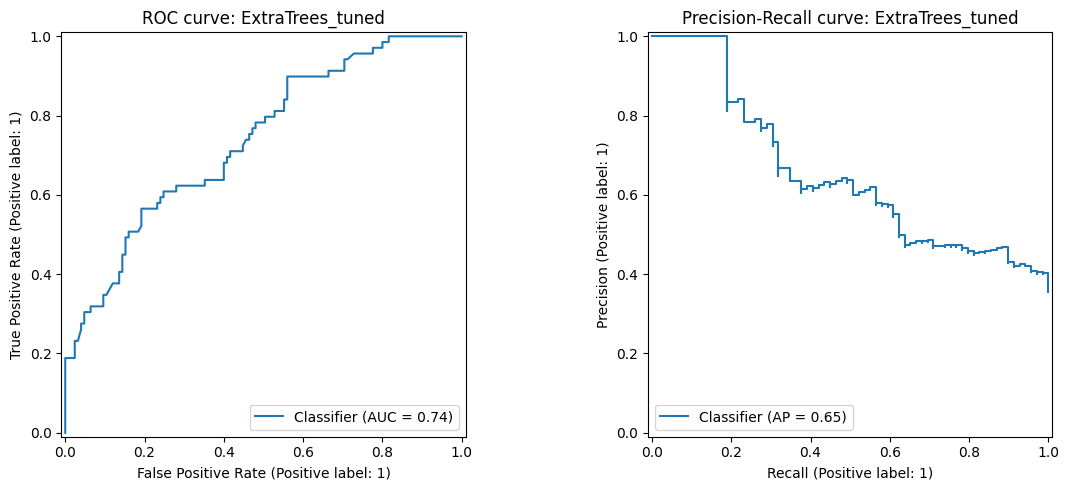

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, best_score, ax=axes[0])
axes[0].set_title(f'ROC curve: {best_model_name}')

PrecisionRecallDisplay.from_predictions(y_test, best_score, ax=axes[1])
axes[1].set_title(f'Precision-Recall curve: {best_model_name}')

plt.tight_layout()
plt.show()

### Диагностика финальной модели

По итоговой таблице лучшей моделью по основной метрике PR_AUC стала ExtraTrees_tuned: PR_AUC = 0.6521, ROC_AUC = 0.7377, accuracy = 0.7010 и F1 = 0.5857. По сравнению с baseline ExtraTrees тюнинг улучшил PR_AUC с 0.6362 до 0.6521, ROC_AUC с 0.7321 до 0.7377, а также повысил recall положительного класса.

Матрица ошибок показывает почти симметричное распределение ошибок: 28 FN и 30 FP. Для задачи с дисбалансом (35.4% положительного класса) это говорит о том, что оптимизация по PR_AUC сработала корректно -- модель не сместилась в сторону предсказания только мажоритарного класса.

Примечательно, что LightGBM_tuned показал лучший ROC_AUC среди всех моделей (0.7459), однако уступил ExtraTrees_tuned по PR_AUC (0.6415 против 0.6521). Это подтверждает правильность выбора PR_AUC как основной метрики: для задачи с дисбалансом ROC_AUC может вводить в заблуждение, завышая оценку качества на мажоритарном классе.

## Важность признаков

Для tree-based моделей используется встроенная feature_importances_. Для линейных моделей используется абсолютное значение коэффициентов. Интерпретация признаков является вспомогательной и требует осторожности.

,feature,importance
0,FractionCSP3,0.042745
1,SMR_VSA7,0.037806
2,NumAliphaticHeterocycles,0.024801
3,fr_allylic_oxid,0.022845
4,NumAliphaticCarbocycles,0.019451
5,MaxAbsEStateIndex,0.017420
6,SMR_VSA4,0.017362
7,NumSaturatedHeterocycles,0.016246
8,RingCount,0.016157
9,EState_VSA8,0.015265


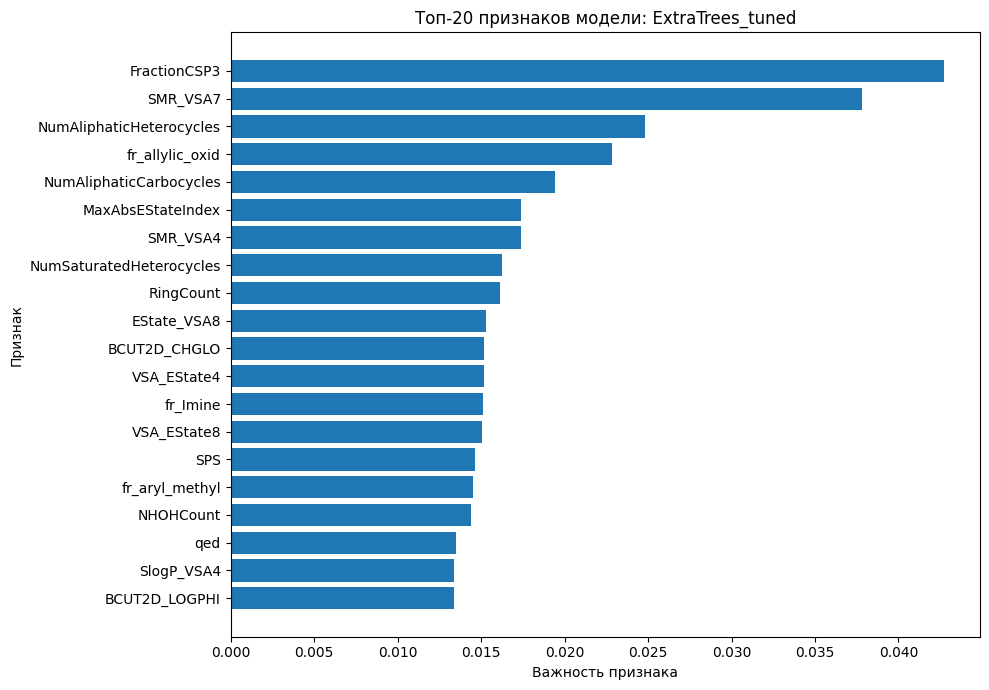

In [45]:
feature_names_best = X_linear.columns if best_feature_set == 'X_linear' else X_tree.columns

final_model = best_model[-1] if isinstance(best_model, Pipeline) else best_model

def plot_importance(importance_df=None):
    if importance_df is not None:
        display(importance_df.head(30))

        plot_imp = importance_df.head(20).iloc[::-1]

        plt.figure(figsize=(10, 7))
        plt.barh(plot_imp['feature'], plot_imp['importance'])
        plt.xlabel('Важность признака')
        plt.ylabel('Признак')
        plt.title(f'Топ-20 признаков модели: {best_model_name}')
        plt.tight_layout()
        plt.show()
    else:
        print('Для выбранной модели нет встроенной важности признаков или коэффициентов.')

importance_df = None

if hasattr(final_model, 'feature_importances_'):
    importance_df = (
        pd.DataFrame({
            'feature': feature_names_best,
            'importance': final_model.feature_importances_
        })
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )

elif hasattr(final_model, 'coef_'):
    importance_df = (
        pd.DataFrame({
            'feature': feature_names_best,
            'coefficient': np.ravel(final_model.coef_)
        })
        .assign(abs_coefficient=lambda x: x['coefficient'].abs())
        .sort_values('abs_coefficient', ascending=False)
        .drop(columns='abs_coefficient')
        .reset_index(drop=True)
    )

plot_importance(importance_df)
    

## Сохранение модели

In [46]:
os.makedirs(MODELS_DIR, exist_ok=True)

model_path = os.path.join(MODELS_DIR, 'best_SI_gt_8_classification_model.joblib')

joblib.dump(best_model, model_path)

print(f'Лучшая модель сохранена: {model_path}')

Лучшая модель сохранена: models/best_SI_gt_8_classification_model.joblib


## Выводы

В ноутбуке решается задача бинарной классификации: превышает ли значение SI порог 8. В отличие от задач классификации по медиане, классы здесь умеренно несбалансированы: по результатам EDA положительный класс SI > 8 составляет около 35.4% наблюдений.

Для сравнения используются две группы моделей: линейные модели на X_linear и tree-based модели на X_tree. Основная метрика - PR_AUC, так как положительный класс менее частый и представляет основной практический интерес. Дополнительно анализируются ROC_AUC, F1, precision, recall, accuracy и balanced_accuracy.

### Сравнение baseline-моделей

На кросс-валидации лучшие значения PR_AUC показали tree-based модели. Наиболее высокие результаты получили RandomForest, XGBoost, LightGBM и ExtraTrees. На тестовой выборке лучший PR_AUC среди baseline-моделей показала ExtraTrees: PR_AUC = 0.6362. Близкие результаты получили RandomForest и XGBoost.

При этом accuracy не является основной метрикой для этой задачи. Dummy_most_frequent достигает accuracy около 0.64 за счёт преобладающего класса 0, но не находит ни одного объекта положительного класса. Поэтому качество моделей оценивается прежде всего по PR_AUC, recall и F1 положительного класса.

У tree-based моделей наблюдается выраженное переобучение: train PR_AUC близок к 0.96-0.99, тогда как CV PR_AUC находится примерно на уровне 0.62-0.65. AdaBoost показал самый низкий overfit gap среди реальных моделей, но уступил лучшим tree-based моделям по PR_AUC.

### Результаты тюнинга

Тюнинг выполнялся по PR_AUC с помощью RandomizedSearchCV. Лучший результат на кросс-валидации показала модель ExtraTrees_tuned: best_cv_PR_AUC = 0.6708. Далее идут RandomForest_tuned, GradientBoosting_tuned, HistGBM_tuned и XGBoost_tuned.

На тестовой выборке лучшей моделью по основной метрике стала ExtraTrees_tuned: PR_AUC = 0.6521, ROC_AUC = 0.7377, accuracy = 0.7010 и F1 = 0.5857. По сравнению с baseline ExtraTrees тюнинг улучшил PR_AUC с 0.6362 до 0.6521 и ROC_AUC с 0.7321 до 0.7377. Также улучшились accuracy, balanced_accuracy, recall и F1.

### Анализ матрицы ошибок

Для финальной модели ExtraTrees_tuned матрица ошибок имеет следующий вид: 95 объектов класса 0 классифицированы верно, 41 объект класса 1 классифицирован верно, 30 объектов класса 0 ошибочно отнесены к классу 1, а 28 объектов класса 1 ошибочно отнесены к классу 0.

Для положительного класса SI > 8 recall = 0.5942. Это означает, что модель находит около 59% соединений с SI > 8 и пропускает оставшуюся часть. Если в практической задаче важнее не пропускать потенциально селективные соединения, следует дополнительно подобрать порог классификации и проверить, можно ли повысить recall при приемлемом снижении precision.

### Важность признаков

Наиболее важными признаками финальной модели стали FractionCSP3, SMR_VSA7, NumAliphaticHeterocycles, fr_allylic_oxid, NumAliphaticCarbocycles, MaxAbsEStateIndex, SMR_VSA4, NumSaturatedHeterocycles, RingCount и EState_VSA8. Эти признаки связаны со структурными, электронными и физико-химическими характеристиками молекул.

Важность признаков следует интерпретировать как модельную оценку вклада RDKit-дескрипторов, а не как доказательство химической причинности. Для строгой химической интерпретации требуется отдельный предметный анализ.

### Рекомендации

- выбирать финальную модель по PR_AUC, а не по accuracy;
- дополнительно анализировать recall и F1 положительного класса SI > 8;
- подобрать порог классификации, если важнее не пропускать селективные соединения;
- рассмотреть альтернативную постановку: отдельно прогнозировать IC50 и CC50, а затем вычислять SI;
- при расширении выборки повторить сравнение моделей, так как положительный класс менее многочислен.
